In [1]:
import os
import joblib
import numpy as np

SAVE_DIR = "/mnt/scratch/projects/rewardMap/reward_signature/model_outputs_reg"
task = "mid"

# Load model
best_model = joblib.load(os.path.join(SAVE_DIR, task, "best_model.joblib"))

# Load data splits
data = np.load(os.path.join(SAVE_DIR, task, "data_splits.npz"))
X_train, X_test = data["X_train"], data["X_test"]
y_train, y_test = data["y_train"], data["y_test"]

# Make predictions
y_pred = best_model.predict(X_test)

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/mnt/projects/rewardMap/STUDIES/reward_signature/.venv/lib64/python3.9/site-packages/traitlets/traitlets.py", line 632, in get
    value = obj._trait_values[self.name]
KeyError: '_control_lock'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/mnt/projects/rewardMap/STUDIES/reward_signature/.venv/lib64/python3.9/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/mnt/projects/rewardMap/STUDIES/reward_signature/.venv/lib64/python3.9/site-packages/ipykernel/kernelbase.py", line 301, in dispatch_control
    async with self._control_lock:
  File "/mnt/projects/rewardMap/STUDIES/reward_signature/.venv/lib64/python3.9/site-packages/traitlets/traitlets.py", line 687, in __get__
    return t.cast(G, self.get(obj, cls))  # the G should encode the Optional
  File "/mnt/projects/rewardMap/ST

/mnt/projects/rewardMap/STUDIES/reward_signature/.venv/lib64/python3.9/site-packages/numpy/_core/fromnumeric.py:820: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



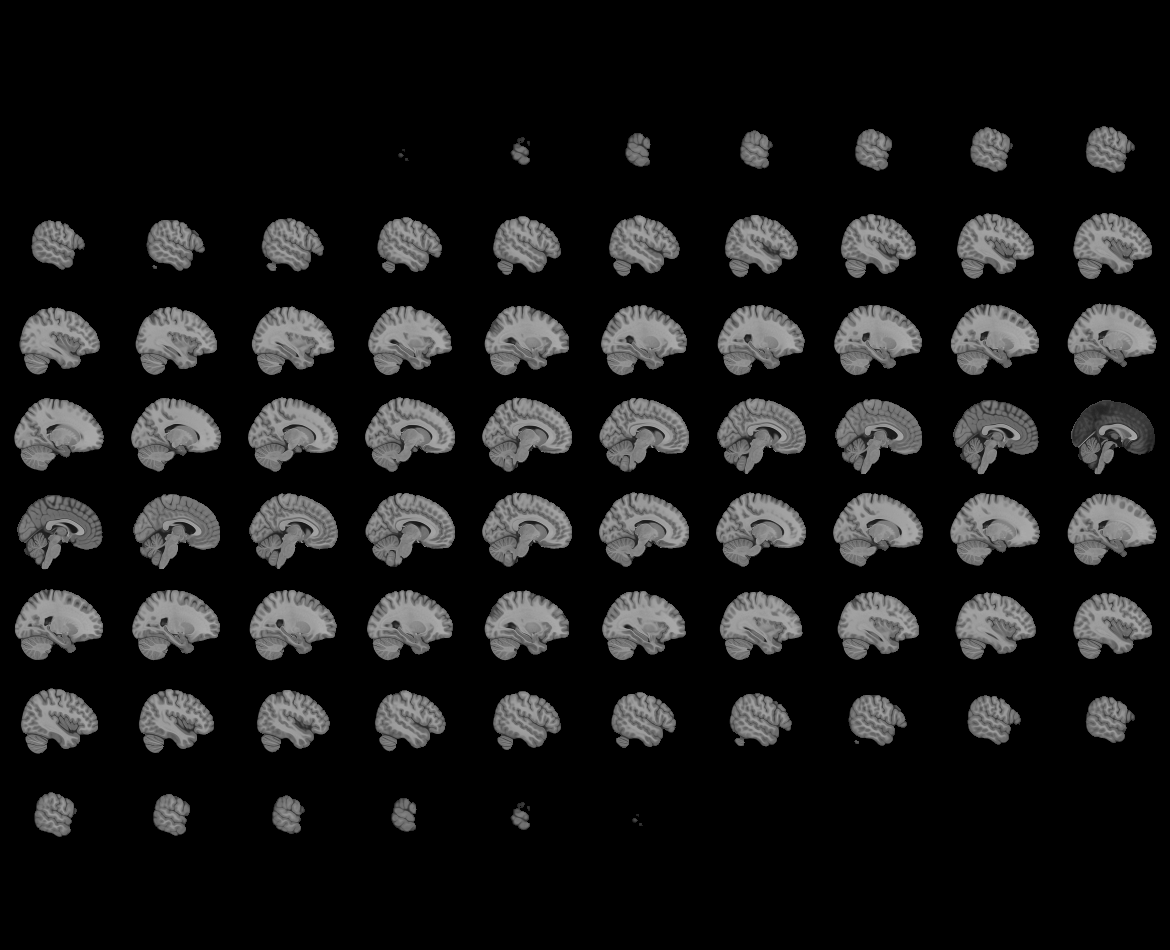
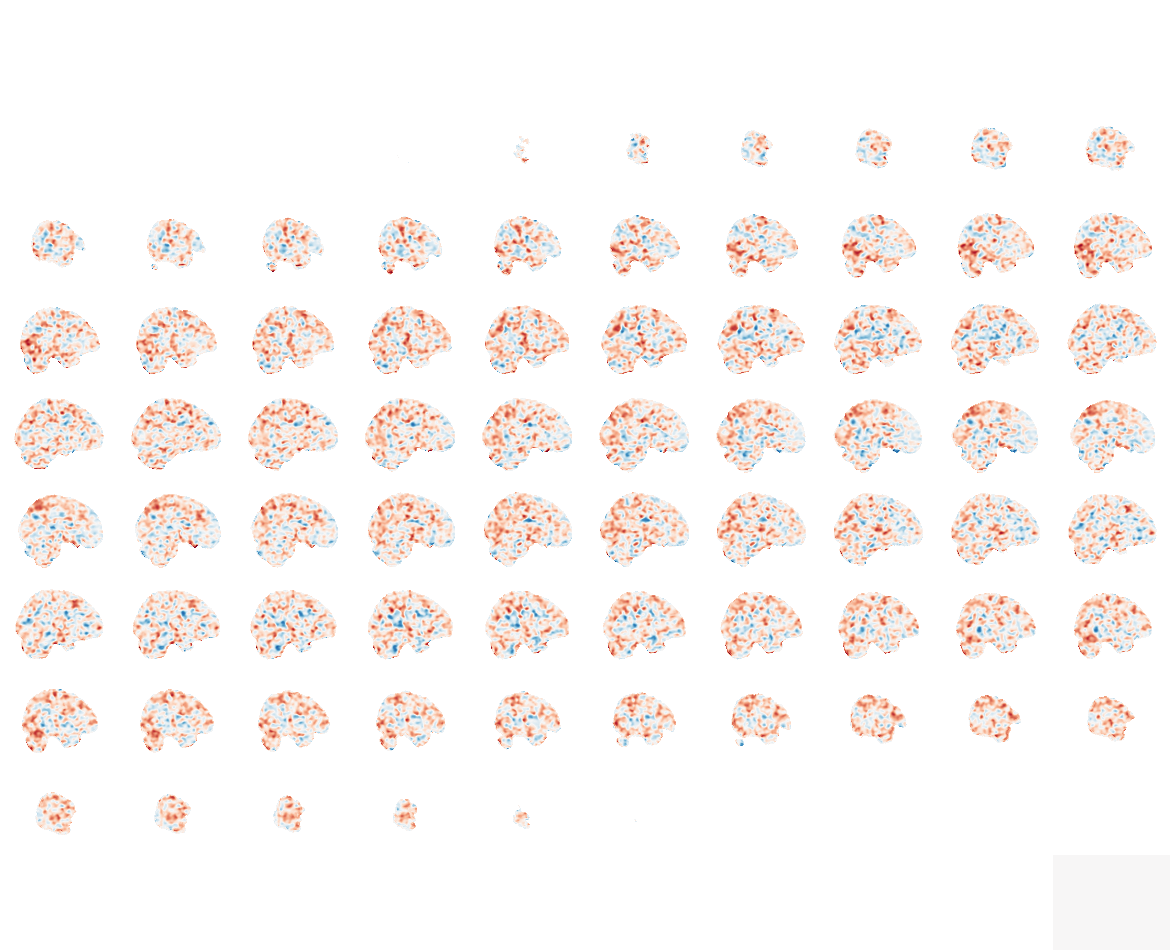

In [ ]:
brain_mask_path = "/mnt/projects/rewardMap/STUDIES/pilotstudy/derivatives/masks/tpl-MNI152NLin2009cAsym_res-02_desc-brain_mask.nii.gz"


pca = best_model["pca"]
model = best_model["model"]

# Transform predictions back to original space
weights_pc = model.coef_
weights_original = pca.inverse_transform(weights_pc)

#unmasking
from nilearn.masking import unmask
weight_map_img = unmask(weights_original, brain_mask_path)
# plot map
from nilearn.plotting import view_img
view_img(weight_map_img, title="Model Weights in Original Space")




In [3]:
from scipy.stats import spearmanr

print(y_test[:30])
print(y_pred[:30])
classes, count = np.unique_counts(y_train)
print(f"Baseline accuracies of Y: {classes} - {np.round(count/np.sum(count), 2)}")
print()

print(np.round(y_pred[:30], 2))

rho, pval = spearmanr(y_test, y_pred)
print(f"Spearman rank correlation: {rho:.4f} (p={pval:.4g})") # we get the ordering partially right yay

[ 0.  0.  0.  0.  0. -1.  0.  0.  0.  0. -5.  0.  0.  0.  0.  5.  5.  0.
  0.  0.  1.  1.  5. -1.  5.  0. -1.  1.  0.  1.]
[0.33521175 0.36075324 0.2592177  0.30018187 0.24958292 0.30617446
 0.2794578  0.32013115 0.27106702 0.3235222  0.3784265  0.33056888
 0.342152   0.41154474 0.3320556  0.37129304 0.3301248  0.34132785
 0.35871497 0.31863657 0.7492694  0.3244145  0.34017882 0.24763243
 0.35608816 0.3034568  0.33115277 0.3322969  0.37105292 0.27847946]
Baseline accuracies of Y: [-5. -1.  0.  1.  5.] - [0.07 0.09 0.59 0.12 0.13]

[0.34 0.36 0.26 0.3  0.25 0.31 0.28 0.32 0.27 0.32 0.38 0.33 0.34 0.41
 0.33 0.37 0.33 0.34 0.36 0.32 0.75 0.32 0.34 0.25 0.36 0.3  0.33 0.33
 0.37 0.28]
Spearman rank correlation: 0.0171 (p=0.8351)


In [41]:
import os
import joblib
import numpy as np

SAVE_DIR = "/mnt/scratch/projects/rewardMap/reward_signature/model_outputs_logreg"
task = "risksensitive"

# Load model
best_model = joblib.load(os.path.join(SAVE_DIR, task, "best_model.joblib"))

# Load data splits
data = np.load(os.path.join(SAVE_DIR, task, "data_splits.npz"))
X_train, X_test = data["X_train"], data["X_test"]
y_train, y_test = data["y_train"], data["y_test"]

# Make predictions
y_pred = best_model.predict(X_test)
probs = best_model.predict_proba(X_test)

(1, 25)
[0.5100935  0.48990652]
Selected idx: (117920,)
weights_original shape: (1, 117920)


/mnt/projects/rewardMap/STUDIES/reward_signature/.venv/lib64/python3.9/site-packages/numpy/_core/fromnumeric.py:820: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/tmp/ipykernel_3839118/2836683921.py:48: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of them.
  view_img(weight_map_img, title="Model Weights in Original Space")



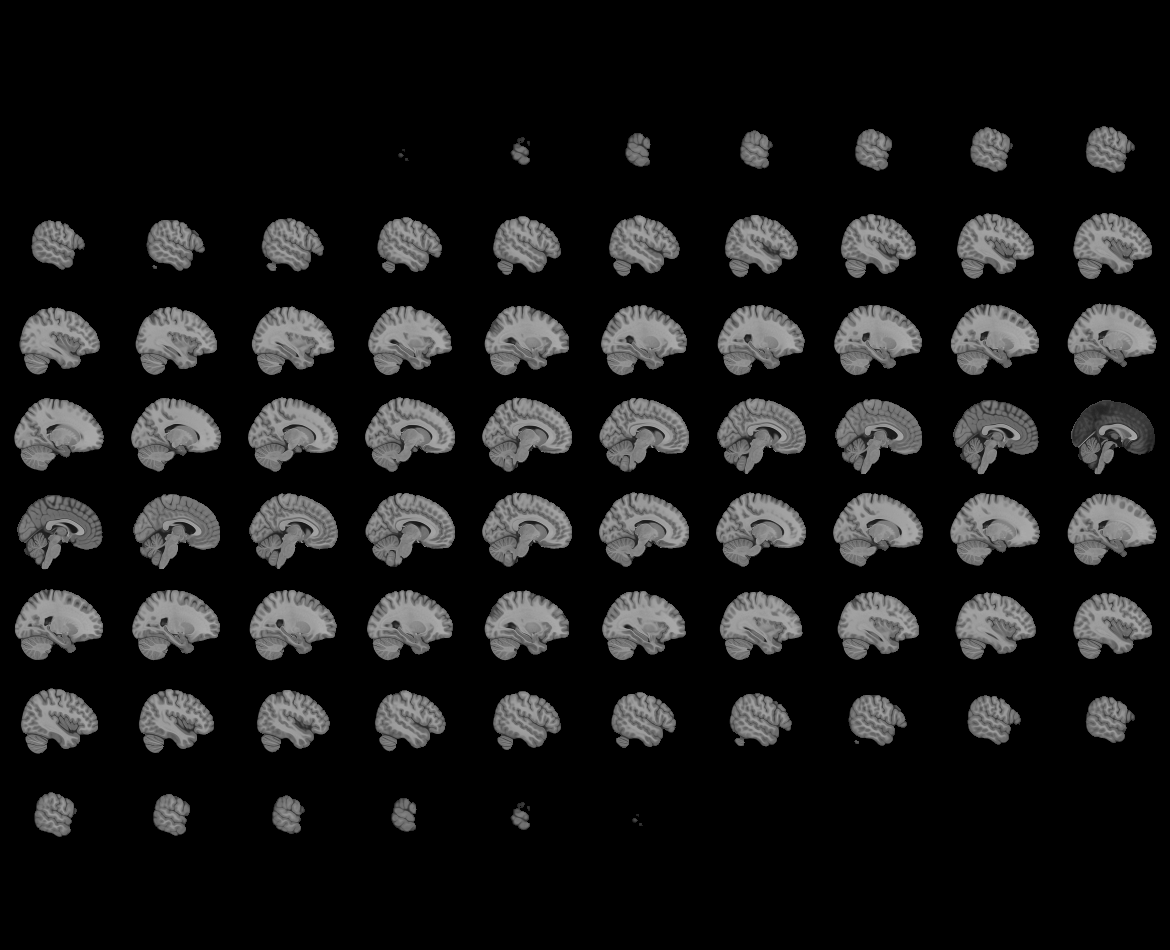
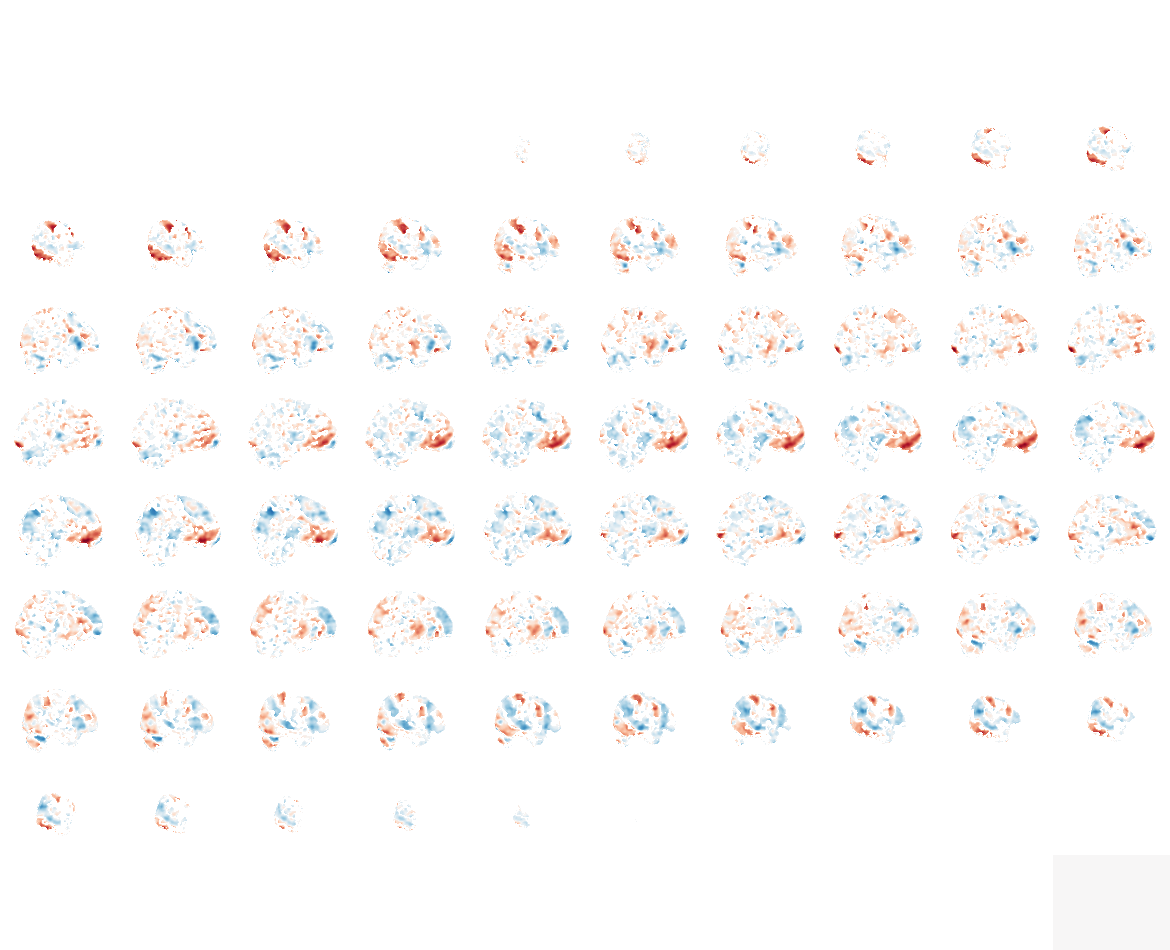

In [42]:
import numpy as np
from nilearn.masking import unmask

brain_mask_path = "/mnt/projects/rewardMap/STUDIES/pilotstudy/derivatives/masks/tpl-MNI152NLin2009cAsym_res-02_desc-brain_mask.nii.gz"

pca = best_model["pca"]
model = best_model["model"]

# Transform PCA-space weights back to masked space
weights_pc = model.coef_
print(weights_pc.shape)
print(np.mean(probs, axis=0))
weights_original = pca.inverse_transform(weights_pc)

selected_idx = best_model["correlate"].selected_idx_
print("Selected idx:", selected_idx.shape)
print("weights_original shape:", weights_original.shape)

# -------------------------------------------------------------
# Construct a full-length weight vector where:
#   - values at selected_idx = weights_original
#   - all other voxels = 0
# -------------------------------------------------------------
# Load the binary brain mask to know its size
from nilearn.masking import compute_brain_mask
import nibabel as nib

mask_img = nib.load(brain_mask_path)
mask_data = mask_img.get_fdata().astype(bool)
n_voxels = mask_data.sum()

# Verify consistency
assert weights_original.shape[1] == len(selected_idx), \
       "Mismatch: weights_original must match number of selected voxels."

# average across classes if multi-class
weights_original = np.mean(weights_original, axis=0)
full_weights = np.zeros(n_voxels)
full_weights[selected_idx] = weights_original

# Now unmask back to 3D
weight_map_img = unmask(full_weights, brain_mask_path)

# -------------------------------------------------------------
# Plot
# -------------------------------------------------------------
from nilearn.plotting import view_img
view_img(weight_map_img, title="Model Weights in Original Space")


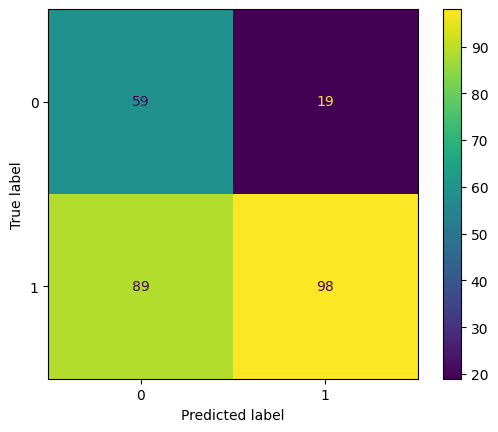

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

MID

In [151]:
import os
import joblib
import numpy as np

SAVE_DIR = "/mnt/scratch/projects/rewardMap/reward_signature/model_outputs_reg_corr"
task = "mid"

# Load model
best_model = joblib.load(os.path.join(SAVE_DIR, task, "best_model.joblib"))

# Load data splits
data = np.load(os.path.join(SAVE_DIR, task, "data_splits.npz"))
X_train, X_test = data["X_train"], data["X_test"]
y_train, y_test = data["y_train"], data["y_test"]

# Make predictions
y_pred = best_model.predict(X_test)

from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print(f"R^2: {r2:.4f}")

from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae:.4f}")

R^2: 0.0209
MAE: 1.4129


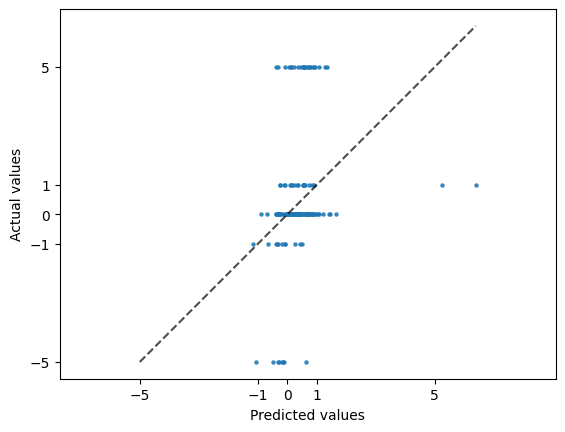

In [162]:
from sklearn.metrics import PredictionErrorDisplay

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import PredictionErrorDisplay

# amount of horizontal jitter (tune as needed)
jitter = 0.0

# jittered version of y_test
#x_jittered = y_test + np.random.uniform(-jitter, jitter, size=len(y_test))

# use jittered x for plotting, but keep actual y_test for the axis ticks
disp = PredictionErrorDisplay.from_predictions(
    y_test,
    y_pred,
    kind='actual_vs_predicted',
    scatter_kwargs={'s': 5}  # smaller points
)

# force axis ticks at -1, 0, 1
plt.xticks(np.unique(y_test))
plt.yticks(np.unique(y_test))
# optionally widen the axis slightly

plt.show()


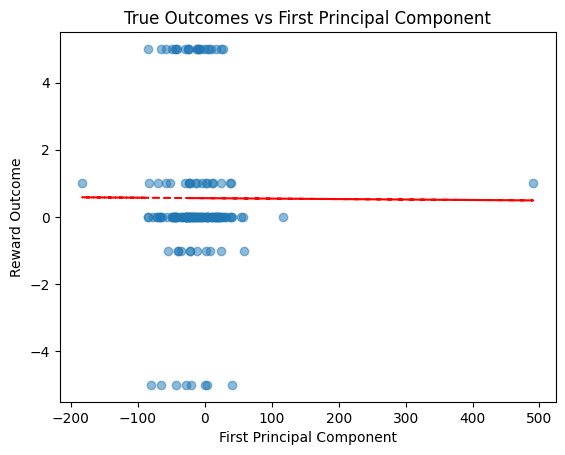

In [157]:
# plot regerssion line on principal components
import matplotlib.pyplot as plt 

corrs = best_model["correlate"].transform(X_test)
pcs = best_model["pca"].transform(corrs)
pc = pcs[:, 0]
plt.scatter(pc, y_test, alpha=0.5)
plt.xlabel("First Principal Component")
plt.ylabel("Reward Outcome")
plt.title("True Outcomes vs First Principal Component")
# add regression line
z = np.polyfit(pc, y_test, 1)
p = np.poly1d(z)
plt.plot(pc, p(pc), "r--")
plt.show()

In [158]:
df = {"y_test": y_test, "y_pred": y_pred, "pc1": pc}

In [76]:
import os
import joblib
import numpy as np

SAVE_DIR = "/mnt/scratch/projects/rewardMap/reward_signature/model_outputs_logreg_nopenalty/"
task = "mid"

# Load model
best_model = joblib.load(os.path.join(SAVE_DIR, task, "best_model.joblib"))

# Load data splits
data = np.load(os.path.join(SAVE_DIR, task, "data_splits.npz"))
X_train, X_test = data["X_train"], data["X_test"]
y_train, y_test = data["y_train"], data["y_test"]

# Make predictions
y_pred = best_model.predict(X_test)
probs = best_model.predict_proba(X_test)

#baseline accuracy
import numpy as np
classes, count = np.unique_counts(y_train)
baseline_acc = np.max(count) / np.sum(count)
print(f"Baseline accuracy of Y: {classes} - {np.round(count/np.sum(count), 2)}")
print(f"Baseline accuracy: {baseline_acc:.4f}")
# accuracy
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

#f1 and balanced accuracy
from sklearn.metrics import f1_score, balanced_accuracy_score
f1 = f1_score(y_test, y_pred, average='macro')
bal_acc = balanced_accuracy_score(y_test, y_pred)

print(f"F1 Score: {f1:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}")

#precision, recall, auprc
from sklearn.metrics import precision_score, recall_score, average_precision_score
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
print(f"Precision: {precision:.4f}")    
print(f"Recall: {recall:.4f}")

Baseline accuracy of Y: [-1.  0.  1.] - [0.15 0.59 0.26]
Baseline accuracy: 0.5911
Accuracy: 0.4867
F1 Score: 0.4892
Balanced Accuracy: 0.5381
Precision: 0.4904
Recall: 0.5381


[[ 0. -0.  0. -0. -0.  0. -0.  0. -0. -0. -0.  0.  0.  0.  0. -0. -0.  0.
  -0. -0.  0.  0. -0. -0.  0.  0. -0.  0.  0.  0. -0. -0. -0.  0.  0. -0.
   0.  0. -0. -0.  0.  0. -0.  0.  0. -0.  0. -0.  0. -0.]
 [-0.  0. -0. -0.  0.  0.  0.  0.  0.  0. -0. -0. -0. -0.  0.  0.  0. -0.
  -0.  0.  0. -0.  0.  0. -0. -0.  0. -0. -0. -0.  0.  0. -0. -0. -0.  0.
  -0. -0.  0.  0.  0.  0.  0. -0. -0.  0. -0.  0. -0. -0.]
 [-0.  0. -0.  0.  0. -0.  0. -0.  0.  0.  0.  0. -0.  0. -0. -0.  0. -0.
   0.  0. -0.  0.  0.  0. -0. -0.  0. -0. -0. -0. -0.  0.  0. -0.  0.  0.
   0.  0.  0.  0. -0. -0. -0. -0. -0. -0.  0. -0. -0.  0.]]
[0.3057807  0.34828386 0.34593537]
Selected idx: (117920,)
weights_original shape: (3, 117920)


/mnt/projects/rewardMap/STUDIES/reward_signature/.venv/lib64/python3.9/site-packages/numpy/_core/fromnumeric.py:820: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/tmp/ipykernel_3839118/2357286376.py:48: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of them.
  view_img(weight_map_img, title="Model Weights in Original Space")



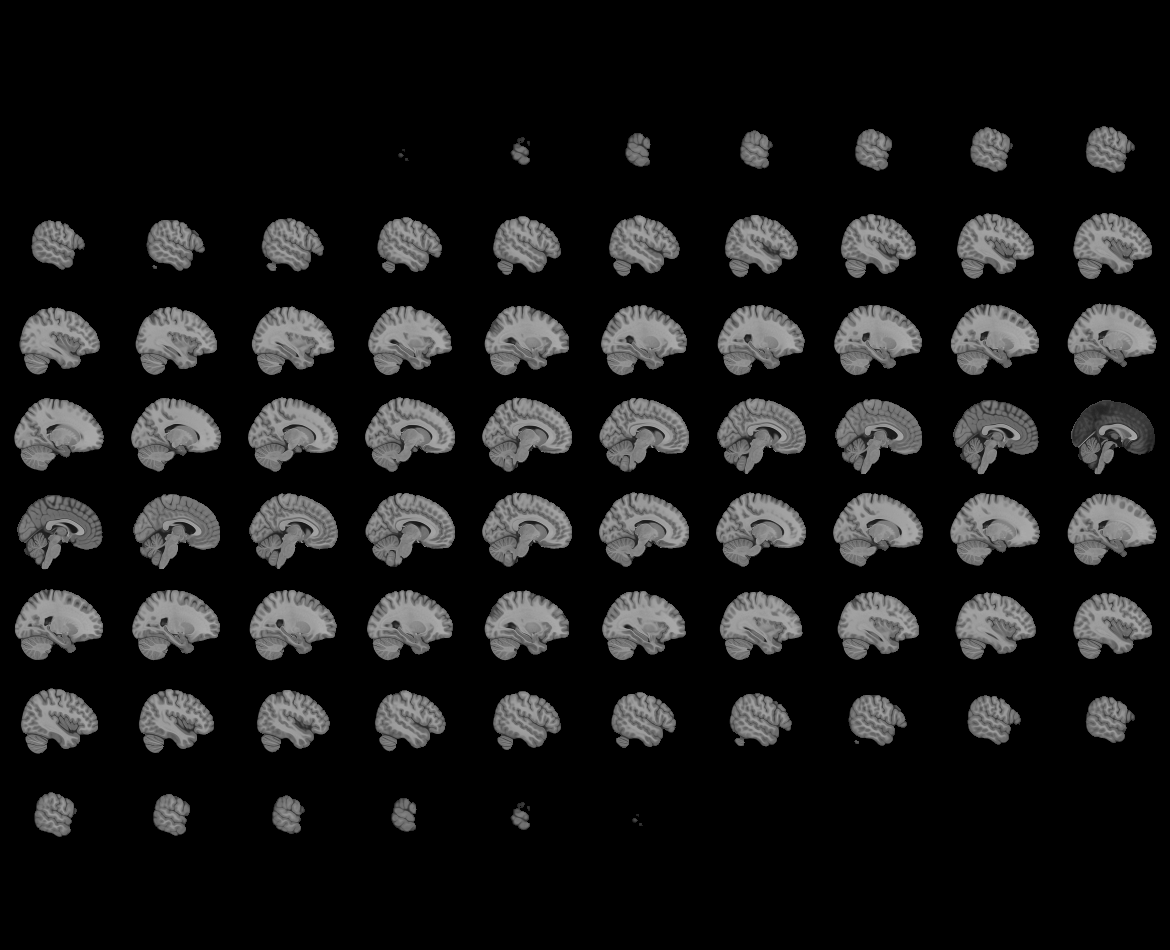
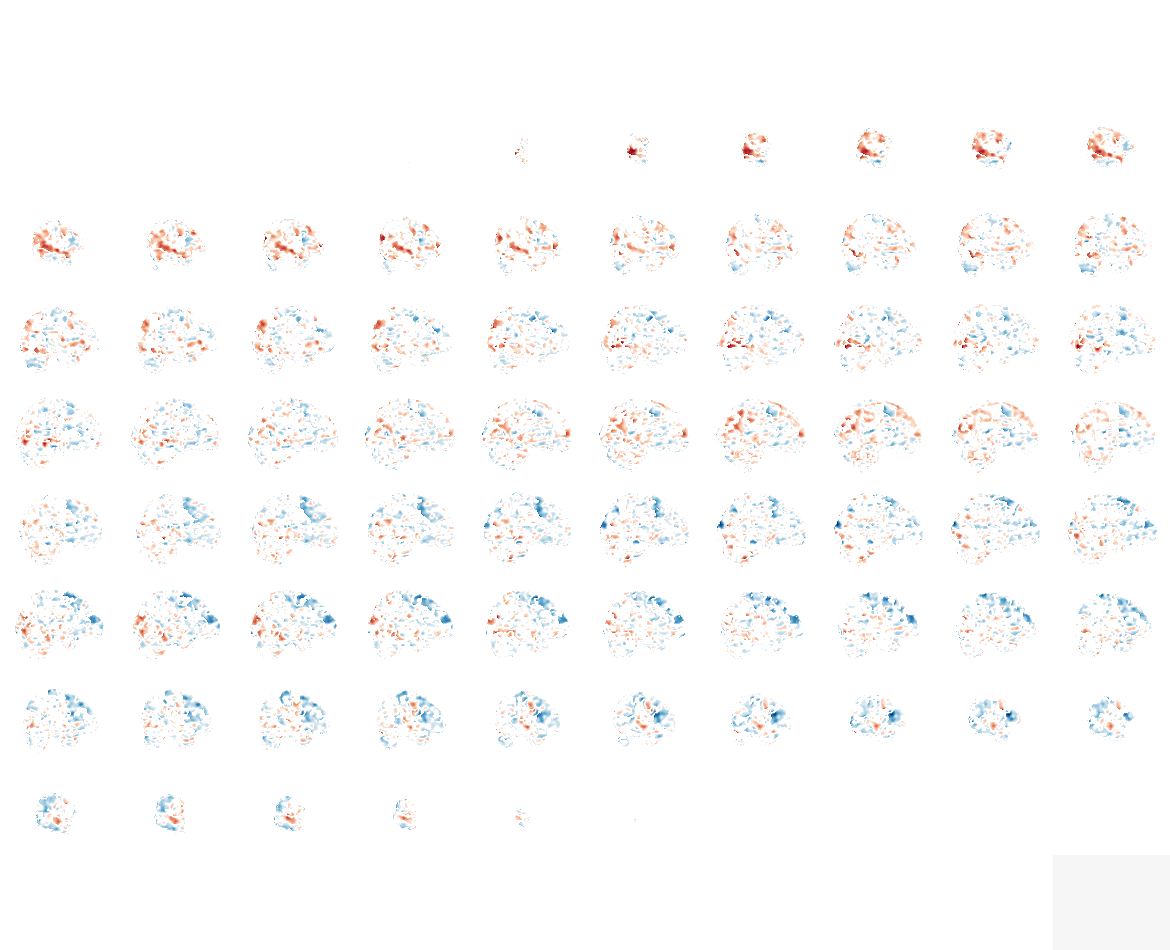

In [77]:
import numpy as np
from nilearn.masking import unmask

brain_mask_path = "/mnt/projects/rewardMap/STUDIES/pilotstudy/derivatives/masks/tpl-MNI152NLin2009cAsym_res-02_desc-brain_mask.nii.gz"

pca = best_model["pca"]
model = best_model["model"]

# Transform PCA-space weights back to masked space
weights_pc = model.coef_
print(np.round(weights_pc))
print(np.mean(probs, axis=0))
weights_original = pca.inverse_transform(weights_pc)

selected_idx = best_model["correlate"].selected_idx_
print("Selected idx:", selected_idx.shape)
print("weights_original shape:", weights_original.shape)

# -------------------------------------------------------------
# Construct a full-length weight vector where:
#   - values at selected_idx = weights_original
#   - all other voxels = 0
# -------------------------------------------------------------
# Load the binary brain mask to know its size
from nilearn.masking import compute_brain_mask
import nibabel as nib

mask_img = nib.load(brain_mask_path)
mask_data = mask_img.get_fdata().astype(bool)
n_voxels = mask_data.sum()

# Verify consistency
assert weights_original.shape[1] == len(selected_idx), \
       "Mismatch: weights_original must match number of selected voxels."

# average across classes if multi-class
weights_original = np.mean(weights_original, axis=0)
full_weights = np.zeros(n_voxels)
full_weights[selected_idx] = weights_original

# Now unmask back to 3D
weight_map_img = unmask(full_weights, brain_mask_path)

# -------------------------------------------------------------
# Plot
# -------------------------------------------------------------
from nilearn.plotting import view_img
view_img(weight_map_img, title="Model Weights in Original Space")


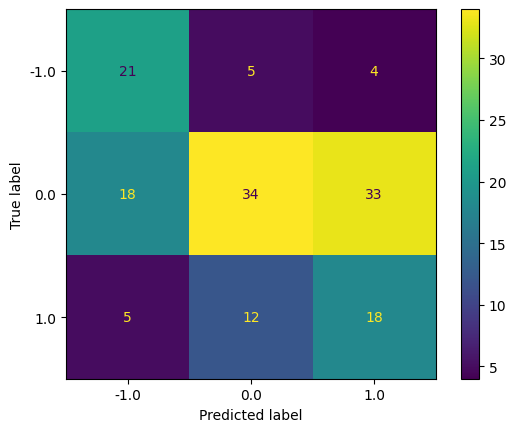

In [78]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model["model"].classes_)
disp.plot()

In [ ]:
from bids import BIDSLayout

def get_subject_data(pidx, db, task, participants, space_name):

    d = {}

    events_files = db.get(
        task=task,
        suffix="events",
        extension="tsv",
        return_type="filename",
        subject=participants[pidx]
    )

    d["event_files"] = events_files

    return d

get_subject_data(0, db, task="mid", participants=["01"], space_name="MNI152NLin2009cAsym")

## regression

In [188]:
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, PredictionErrorDisplay
from nilearn.masking import unmask
import nibabel as nib
import base64
from io import BytesIO
from nilearn.plotting import plot_stat_map

def fig_to_base64(fig):
    buf = BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=150)
    buf.seek(0)
    return base64.b64encode(buf.read()).decode("utf-8")

def generate_report(
    task: str,
    save_dir: str = "/mnt/scratch/projects/rewardMap/reward_signature/model_outputs_reg_corr",
    brain_mask_path: str = "/mnt/projects/rewardMap/STUDIES/pilotstudy/derivatives/masks/tpl-MNI152NLin2009cAsym_res-02_desc-brain_mask.nii.gz",
    output_html: str = None
):
    report_sections = []

    # ---------------------------
    # Load model + data
    # ---------------------------
    model_path = os.path.join(save_dir, task, "best_model.joblib")
    data_path = os.path.join(save_dir, task, "data_splits.npz")

    best_model = joblib.load(model_path)
    data = np.load(data_path)
    X_train, X_test = data["X_train"], data["X_test"]
    y_train, y_test = data["y_train"], data["y_test"]

    y_pred = best_model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    # ---------------------------
    # Plot 1 — prediction scatter
    # ---------------------------
    fig1, ax1 = plt.subplots(figsize=(4, 4))
    disp = PredictionErrorDisplay.from_predictions(
        y_test, y_pred, kind='actual_vs_predicted', scatter_kwargs={'s': 5}, ax=ax1
    )
    ax1.set_title("Prediction: Actual vs Predicted")
    b64_plot1 = fig_to_base64(fig1)
    plt.close(fig1)

    # ---------------------------
    # PCA projection plots — GRID
    # ---------------------------
    corrs = best_model["correlate"].transform(X_test)
    pcs = best_model["pca"].transform(corrs)
    n_pcs = pcs.shape[1]

    # Define grid
    n_cols = 4
    n_rows = int(np.ceil(n_pcs / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
    axes = axes.flatten()

    for i in range(n_pcs):
        ax = axes[i]
        pc = pcs[:, i]

        ax.scatter(pc, y_test, alpha=0.5, s=8)
        z = np.polyfit(pc, y_test, 1)
        p = np.poly1d(z)
        ax.plot(pc, p(pc), "r--", linewidth=1)

        ax.set_xlabel(f"PC {i+1}")
        ax.set_ylabel("Outcome")
        ax.set_title(f"Outcome vs PC{i+1}")

    # hide unused axes
    for j in range(i+1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    b64_pc_grid = fig_to_base64(fig)
    plt.close(fig)

    # ---------------------------
    # Reconstruct weight map
    # ---------------------------
    pca = best_model["pca"]
    mdl = best_model["model"]

    weights_pc = mdl.coef_
    weights_original = pca.inverse_transform(weights_pc)

    selected_idx = best_model["correlate"].selected_idx_

    mask_img = nib.load(brain_mask_path)
    mask_data = mask_img.get_fdata().astype(bool)
    n_voxels = mask_data.sum()

    if weights_original.ndim == 2:
        weights_original = np.mean(weights_original, axis=0)

    full_weights = np.zeros(n_voxels)
    full_weights[selected_idx] = weights_original

    weight_map_img = unmask(full_weights, brain_mask_path)

    # ---------------------------
    # weight map to static png
    # ---------------------------
    view = view_img(weight_map_img, title="Model Weights")
    weight_map_html = view._repr_html_()  # get embeddable HTML

    # ---------------------------
    # Build HTML
    # ---------------------------
    html = f"""
    <html>
    <head>
        <title>Report for Task: {task}</title>
        <style>
            body {{ font-family: Arial, sans-serif; margin: 40px; }}
            h1 {{ color: #333; }}
            img {{ max-width: 700px; margin-bottom: 20px; }}
            iframe {{ width: 700px; height: 500px; border: none; margin-bottom: 20px; }}
        </style>
    </head>
    <body>
        <h1>Model Report: {task}</h1>

        <h2>Performance</h2>
        <p><b>R²:</b> {r2:.4f}</p>
        <p><b>MAE:</b> {mae:.4f}</p>

        <h2>Actual vs Predicted</h2>
        <img src="data:image/png;base64,{b64_plot1}"/>

        <h2>PCA Regression Plots</h2>
        <img src="data:image/png;base64,{b64_pc_grid}"/>

        <h2>Weight Map (Interactive)</h2>
        {weight_map_html}  <!-- directly embed the HTML snippet -->
    </body>
    </html>
    """

    if output_html is None:
        output_html = f"reports/{task}_regression_report.html"

    with open(output_html, "w") as f:
        f.write(html)

    print(f"HTML report saved to: {output_html}")
    return output_html

generate_report(task="twostep")


/mnt/projects/rewardMap/STUDIES/reward_signature/.venv/lib64/python3.9/site-packages/numpy/_core/fromnumeric.py:820: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/tmp/ipykernel_3839118/3676794340.py:114: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of them.
  view = view_img(weight_map_img, title="Model Weights")


HTML report saved to: twostep_regression_report.html


'twostep_regression_report.html'

## classification

In [189]:
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt
from io import BytesIO
import base64
import nibabel as nib
from nilearn.masking import unmask
from nilearn.plotting import plot_stat_map
from sklearn.metrics import (
    accuracy_score, f1_score, balanced_accuracy_score,
    precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
)

def fig_to_base64(fig):
    buf = BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=150)
    buf.seek(0)
    return base64.b64encode(buf.read()).decode("utf-8")

def generate_classification_report(
    task: str,
    save_dir: str = "/mnt/scratch/projects/rewardMap/reward_signature/model_outputs_logreg_nopenalty/",
    brain_mask_path: str = "/mnt/projects/rewardMap/STUDIES/pilotstudy/derivatives/masks/tpl-MNI152NLin2009cAsym_res-02_desc-brain_mask.nii.gz",
    output_html: str = None
):
    # ---------------------------
    # Load model + data
    # ---------------------------
    model_path = os.path.join(save_dir, task, "best_model.joblib")
    data_path = os.path.join(save_dir, task, "data_splits.npz")

    best_model = joblib.load(model_path)
    model = best_model["model"]
    data = np.load(data_path)
    X_train, X_test = data["X_train"], data["X_test"]
    y_train, y_test = data["y_train"], data["y_test"]

    pca = best_model["pca"]

    y_pred = best_model.predict(X_test)
    
    # ---------------------------
    # Baseline accuracy
    # ---------------------------
    classes, counts = np.unique(y_train, return_counts=True)
    baseline_acc = np.max(counts) / np.sum(counts)
    
    # ---------------------------
    # Metrics
    # ---------------------------
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')

    # ---------------------------
    # Confusion matrix
    # ---------------------------
    cm = confusion_matrix(y_test, y_pred)
    fig_cm, ax_cm = plt.subplots(figsize=(4,4))
    disp = ConfusionMatrixDisplay(cm, display_labels=model.classes_)
    disp.plot(ax=ax_cm, cmap="Blues", colorbar=False)
    ax_cm.set_title("Confusion Matrix")
    cm_b64 = fig_to_base64(fig_cm)
    plt.close(fig_cm)

    # ---------------------------
    # Weight map (PCA back-projection)
    # ---------------------------
    weights_pc = model.coef_
    weights_original = pca.inverse_transform(weights_pc)

    selected_idx = best_model["correlate"].selected_idx_
    weights_original = np.mean(weights_original, axis=0)  # average across classes if multiclass

    mask_img = nib.load(brain_mask_path)
    mask_data = mask_img.get_fdata().astype(bool)
    n_voxels = mask_data.sum()

    full_weights = np.zeros(n_voxels)
    full_weights[selected_idx] = weights_original
    weight_map_img = unmask(full_weights, brain_mask_path)

    fig_map = view_img(weight_map_img, title="Model Weights")._repr_html_()  # get embeddable HTML


    # ---------------------------
    # Build HTML report
    # ---------------------------
    if output_html is None:
        output_html = f"reports/{task}_classification_report.html"

    html = f"""
    <html>
    <head>
        <title>Classification Report: {task}</title>
        <style>
            body {{ font-family: Arial, sans-serif; margin: 40px; }}
            h1 {{ color: #333; }}
            img {{ max-width: 700px; margin-bottom: 20px; }}
        </style>
    </head>
    <body>
        <h1>Classification Report: {task}</h1>

        <h2>Baseline Accuracy</h2>
        <p><b>Classes:</b> {classes}</p>
        <p><b>Class distribution:</b> {np.round(counts/np.sum(counts),2)}</p>
        <p><b>Baseline accuracy:</b> {baseline_acc:.4f}</p>

        <h2>Performance Metrics</h2>
        <p><b>Accuracy:</b> {acc:.4f}</p>
        <p><b>F1 Score:</b> {f1:.4f}</p>
        <p><b>Balanced Accuracy:</b> {bal_acc:.4f}</p>
        <p><b>Precision:</b> {precision:.4f}</p>
        <p><b>Recall:</b> {recall:.4f}</p>

        <h2>Confusion Matrix</h2>
        <img src="data:image/png;base64,{cm_b64}"/>

        <h2>Weight Map</h2>
        {fig_map}
    </body>
    </html>
    """

    with open(output_html, "w") as f:
        f.write(html)

    print(f"HTML classification report saved to: {output_html}")
    return output_html
generate_classification_report(task="twostep")


/mnt/projects/rewardMap/STUDIES/reward_signature/.venv/lib64/python3.9/site-packages/numpy/_core/fromnumeric.py:820: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/tmp/ipykernel_3839118/588454207.py:86: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of them.
  fig_map = view_img(weight_map_img, title="Model Weights")._repr_html_()  # get embeddable HTML


HTML classification report saved to: twostep_classification_report.html


'twostep_classification_report.html'

In [197]:
import os
import pandas as pd
import numpy as np
import nibabel as nb



from bids import BIDSLayout
from nilearn.interfaces.fmriprep import load_confounds
from tqdm import tqdm
from nilearn.glm.first_level import FirstLevelModel


def get_subject_data(pidx, db, task, participants, space_name):
    """
    Loads bids compliant fMRI data for a single subject.

    Input:
        subject-id
    
    Returns:
        dictionary containing subject data

    """

    d = {}

    events_files = db.get(
        task=task,
        suffix="events",
        extension="tsv",
        return_type="filename",
        subject=participants[pidx]
    )

    d["event_files"] = events_files

    bold_files = db.get(
        task=task,
        suffix="bold",
        space=space_name,
        extension="nii.gz",
        return_type="filename",
        res="02",
        subject=participants[pidx]
    )

    # mask = db.get(
    #     task=task,
    #     suffix="mask",
    #     space=space_name,
    #     extension="nii.gz",
    #     return_type="filename",
    #     res="02",
    #     subject=participants[pidx]
    # )

    d["bold_files"] = bold_files

    tr=db.get(
        task=task,
        suffix="bold",
        space=space_name,
        extension="nii.gz",
        res="02",
        subject=participants[pidx]
    )[0].get_metadata()['RepetitionTime']

    d["tr"] = tr

    n_frames = nb.load(bold_files[0]).shape[-1]
    frame_times = np.arange(n_frames) * tr + tr /2

    d["n_frames"] = n_frames
    d["frame_times"] = frame_times

    d["confounds"] = load_confounds(bold_files, strategy=("motion", "wm_csf"))[0]

    return d

db = BIDSLayout(root="/mnt/projects/rewardMap/STUDIES/pilotstudy/derivatives/", database_path='/mnt/projects/rewardMap/STUDIES/pilotstudy/derivatives/bids_layout/')
tmp_files = db.get(
        task=task,
        suffix="events",
        extension="tsv",
        return_type="filename"
    )

participants = [i.split('/')[-4].split('-')[-1] for i in tmp_files]
space_name = "MNI152NLin2009cAsym"

get_subject_data(1, db, task="mid", participants=participants, space_name=space_name)

{'event_files': ['/mnt/projects/rewardMap/STUDIES/pilotstudy/rawdata/sub-rwm002/ses-02/func/sub-rwm002_ses-02_task-mid_acq-te14ipat2mb2me3pf78_dir-AP_run-02_events.tsv'],
 'bold_files': ['/mnt/projects/rewardMap/STUDIES/pilotstudy/derivatives/fmriprep-25.0.0/sub-rwm002/ses-02/func/sub-rwm002_ses-02_task-mid_acq-te14ipat2mb2me3pf78_dir-AP_run-02_part-mag_space-MNI152NLin2009cAsym_res-02_desc-preproc_bold.nii.gz'],
 'tr': 1.8,
 'n_frames': 381,
 'frame_times': array([  0.9,   2.7,   4.5,   6.3,   8.1,   9.9,  11.7,  13.5,  15.3,
         17.1,  18.9,  20.7,  22.5,  24.3,  26.1,  27.9,  29.7,  31.5,
         33.3,  35.1,  36.9,  38.7,  40.5,  42.3,  44.1,  45.9,  47.7,
         49.5,  51.3,  53.1,  54.9,  56.7,  58.5,  60.3,  62.1,  63.9,
         65.7,  67.5,  69.3,  71.1,  72.9,  74.7,  76.5,  78.3,  80.1,
         81.9,  83.7,  85.5,  87.3,  89.1,  90.9,  92.7,  94.5,  96.3,
         98.1,  99.9, 101.7, 103.5, 105.3, 107.1, 108.9, 110.7, 112.5,
        114.3, 116.1, 117.9, 119.7, 121.5

In [201]:
np.load("../brain_masked/lss_z_maps/hcp/betas_sub_000.npy").shape

(63, 235840)